# Пространственно-временной анализ ДТП в Москве

В данном ноутбуке выполнена предварительная обработка и анализ данных о дорожно-транспортных происшествиях в Москве. Основное внимание уделено временным закономерностям ДТП, погодным условиям, состоянию дорожного покрытия и тяжести последствий.

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import folium
import branca.colormap as cm
from branca.element import MacroElement
from jinja2 import Template
from IPython.display import HTML

In [89]:
file = "accidents_ed.csv"

In [90]:
try:
    df = pd.read_csv(file, sep=';', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(file, sep=';', encoding='cp1251')

In [91]:
df["datetime"] = pd.to_datetime(df["datetime"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["datetime"])

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.dayofweek  
df["month"] = df["datetime"].dt.month

weekday_names = ["Понедельник","Вторник","Среда","Четверг","Пятница","Суббота","Воскресенье"]
month_names = ["Январь","Февраль","Март","Апрель","Май","Июнь","Июль","Август","Сентябрь","Октябрь","Ноябрь","Декабрь"]

In [92]:
df

,OID_,id,tags,category,region,county,address,longitude,latitude,nearby,...,weather,road_conditions,participants_count,participant_categories,severity,dead_count,injured_count,hour,weekday,month
0,1,2535703,Дорожно-транспортные происшествия,Наезд на пешехода,Москва,Киевский,"тер СНТ Полесье, 47","36,820765000000002","55,432422000000003",Жилые дома индивидуальной застройки,...,Пасмурно,Заснеженное,2,"Пешеходы, Все участники",С погибшими,1,0,0,3,1
1,2,2962431,Дорожно-транспортные происшествия,Столкновение,Москва,Киевский,"рп Киевский, снт Березка, 20","36,825195999999998","55,435405000000003",Регулируемый ж/д переезд без дежурного,...,Ясно,Сухое,2,Все участники,Тяжёлый,0,1,21,2,4
2,3,1570323,Дорожно-транспортные происшествия,Наезд на препятствие,Москва,Киевский,NaN,"36,833851000000003","55,427114000000003",NaN,...,Ясно,"Сухое, Недостатки зимнего содержания",1,"Мотоциклисты, Все участники",Тяжёлый,0,1,15,5,3
3,4,1560899,"Дорожно-транспортные происшествия, ДТП и постр...",Опрокидывание,Москва,Киевский,"рп Киевский, ул Бекасовская, 1","36,838895999999998","55,430438000000002",NaN,...,Ясно,Сухое,1,"Мотоциклисты, Дети, Все участники",Тяжёлый,0,1,14,6,8
4,5,2553189,"Дорожно-транспортные происшествия, ДТП и постр...",Наезд на препятствие,Москва,Киевский,М-3 Украина Москва - Калуга - Брянск - граница...,"36,841760999999998","55,418838999999998",Регулируемый перекресток,...,Снегопад,Мокрое,6,"Дети, Все участники",Тяжёлый,0,5,20,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79485,79486,1534246,Дорожно-транспортные происшествия,Столкновение,Москва,Савеловский,"г Москва, пер Вятский 4-й, 35","37,571389000000003","55,799999999999997",Многоквартирные жилые дома,...,Ясно,Сухое,3,Все участники,Тяжёлый,0,1,17,0,6
79486,79487,1549610,Дорожно-транспортные происшествия,Столкновение,Москва,Богородское,"г Москва, ул Краснобогатырская, 87","37,711326999999997","55,801392000000000","Многоквартирные жилые дома, Нерегулируемый пер...",...,Пасмурно,Сухое,2,"Мотоциклисты, Все участники",Тяжёлый,0,1,21,2,7
79487,79488,1534259,Дорожно-транспортные происшествия,Наезд на велосипедиста,Москва,Коптево,"г Москва, проезд Черепановых, 24 А","37,523055999999997","55,840000000000003","Многоквартирные жилые дома, АЗС, Нерегулируемы...",...,Ясно,Сухое,2,"Велосипедисты, Все участники",Тяжёлый,0,1,10,4,6
79488,79489,1543199,Дорожно-транспортные происшествия,Столкновение,Москва,Северное Тушино,"г Москва, км МКАД 74-й","37,429600000000001","55,877099999999999",Крупный торговый объект (являющийся объектом м...,...,Пасмурно,Сухое,8,Все участники,Легкий,0,5,1,5,9


In [93]:
df['weather'].unique()

array(['Пасмурно', 'Ясно', 'Снегопад', 'Дождь', 'Пасмурно, Снегопад',
       'Пасмурно, Дождь', 'Ясно, Температура выше +30С', 'Туман',
       'Пасмурно, Туман', 'Пасмурно, Температура выше +30С', 'Метель',
       'Ясно, Дождь', 'Дождь, Туман', 'Пасмурно, Метель',
       'Снегопад, Метель', 'Дождь, Снегопад',
       'Ясно, Температура ниже -30С'], dtype=object)

In [94]:
weather_counts = df['weather'].value_counts()

print(weather_counts)

weather
Пасмурно                           40170
Ясно                               34049
Дождь                               2989
Снегопад                            1644
Пасмурно, Дождь                      364
Пасмурно, Снегопад                   175
Ясно, Температура выше +30С           33
Туман                                 22
Метель                                13
Дождь, Снегопад                       11
Пасмурно, Туман                        8
Снегопад, Метель                       4
Ясно, Дождь                            3
Пасмурно, Метель                       2
Пасмурно, Температура выше +30С        1
Дождь, Туман                           1
Ясно, Температура ниже -30С            1
Name: count, dtype: int64


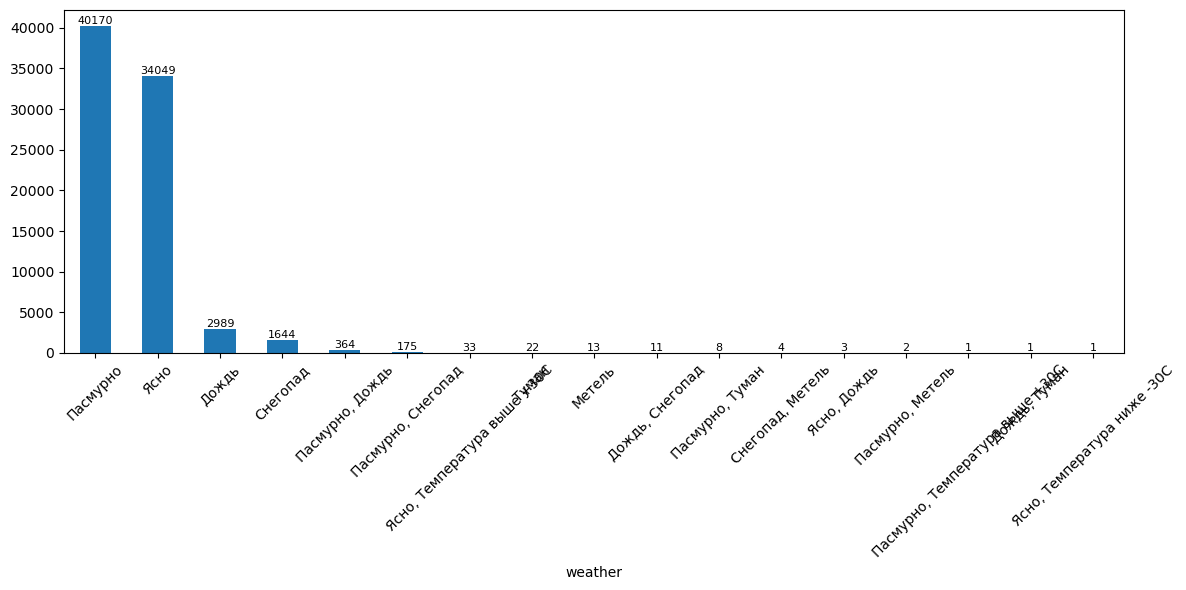

In [95]:
plt.figure(figsize=(12,6))
ax = weather_counts.plot(kind='bar')

for i, v in enumerate(weather_counts):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [96]:
df['light'].unique()

array(['В темное время суток, освещение включено', 'Светлое время суток',
       'В темное время суток, освещение отсутствует', 'Сумерки',
       'В темное время суток, освещение не включено', 'Не установлено'],
      dtype=object)

In [97]:
light_counts = df['light'].value_counts()

print(light_counts)

light
Светлое время суток                            47551
В темное время суток, освещение включено       30217
Сумерки                                         1172
В темное время суток, освещение отсутствует      394
В темное время суток, освещение не включено      154
Не установлено                                     2
Name: count, dtype: int64


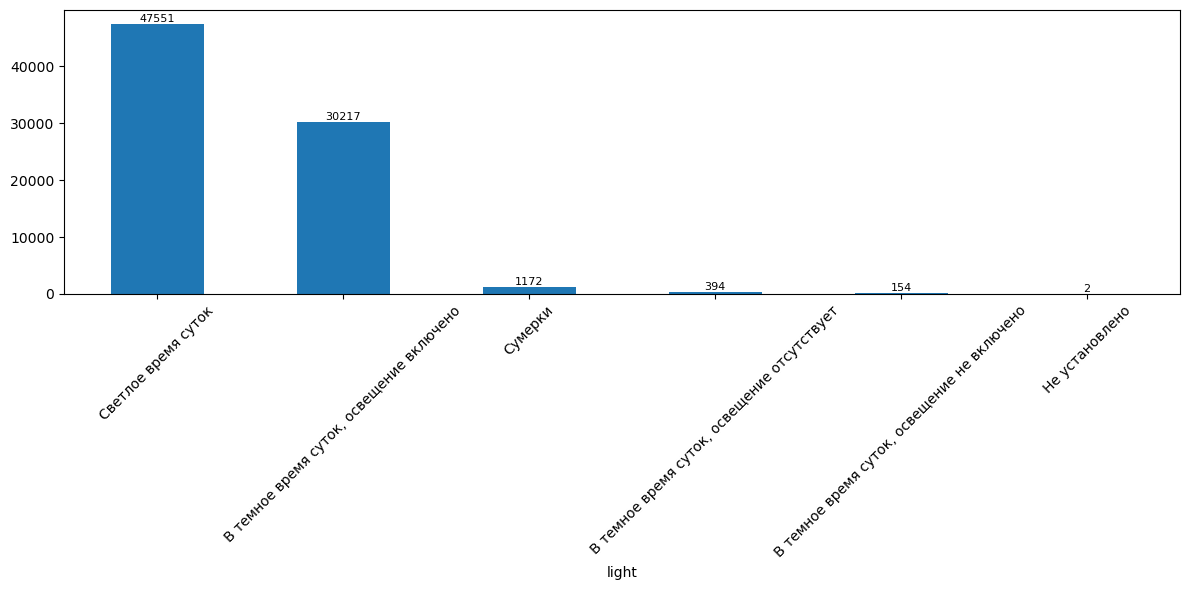

In [98]:
plt.figure(figsize=(12,6))
ax = light_counts.plot(kind='bar')

for i, v in enumerate(light_counts):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

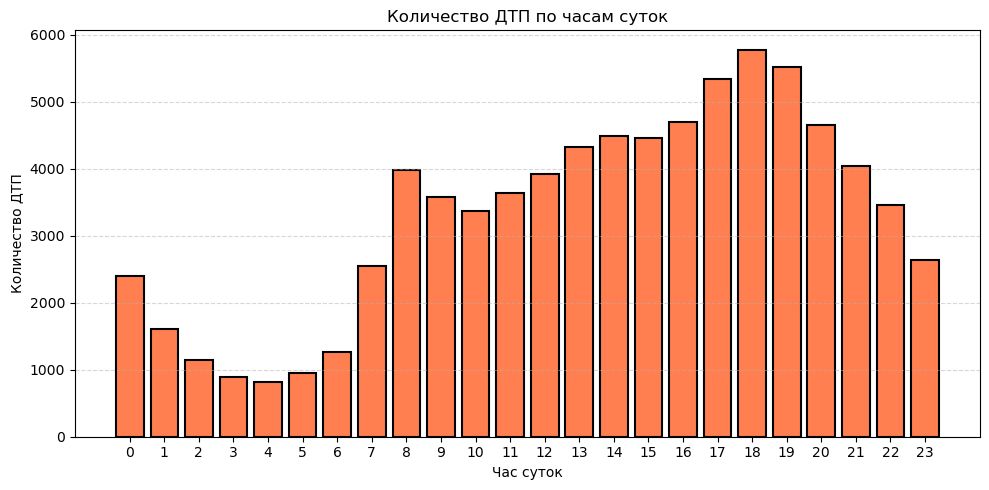

<Figure size 640x480 with 0 Axes>

In [121]:
hourly_counts = df.groupby("hour").size().reindex(range(24), fill_value=0)


plt.figure(figsize=(10,5))

plt.bar(
    hourly_counts.index, 
    hourly_counts.values,
    color="#FF7F50",      
    edgecolor="black",    
    linewidth=1.5         
)

plt.xticks(range(24))
plt.xlabel("Час суток")
plt.ylabel("Количество ДТП")
plt.title("Количество ДТП по часам суток")

plt.grid(axis='y', linestyle='--', alpha=0.5)  

plt.tight_layout()
plt.show()
plt.savefig("dtp_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()

In [100]:
plt.savefig("dtp_by_hour.png", dpi=300, bbox_inches="tight") 

plt.show()

<Figure size 640x480 with 0 Axes>

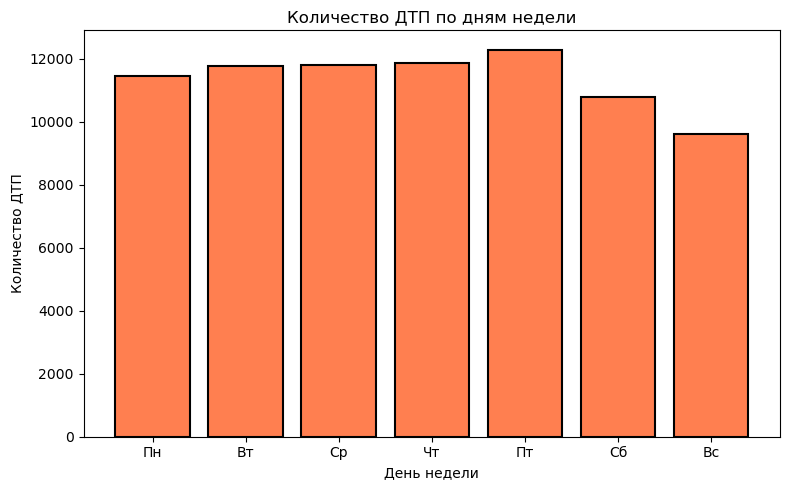

In [101]:
weekday_counts = df.groupby("weekday").size().reindex(range(7), fill_value=0)

days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

plt.figure(figsize=(8,5))

plt.bar(
    weekday_counts.index, 
    weekday_counts.values,
    color="#FF7F50",
    edgecolor="black",
    linewidth=1.5
)

plt.xticks(ticks=range(7), labels=days)
plt.xlabel("День недели")
plt.ylabel("Количество ДТП")
plt.title("Количество ДТП по дням недели")

plt.tight_layout()
plt.show()

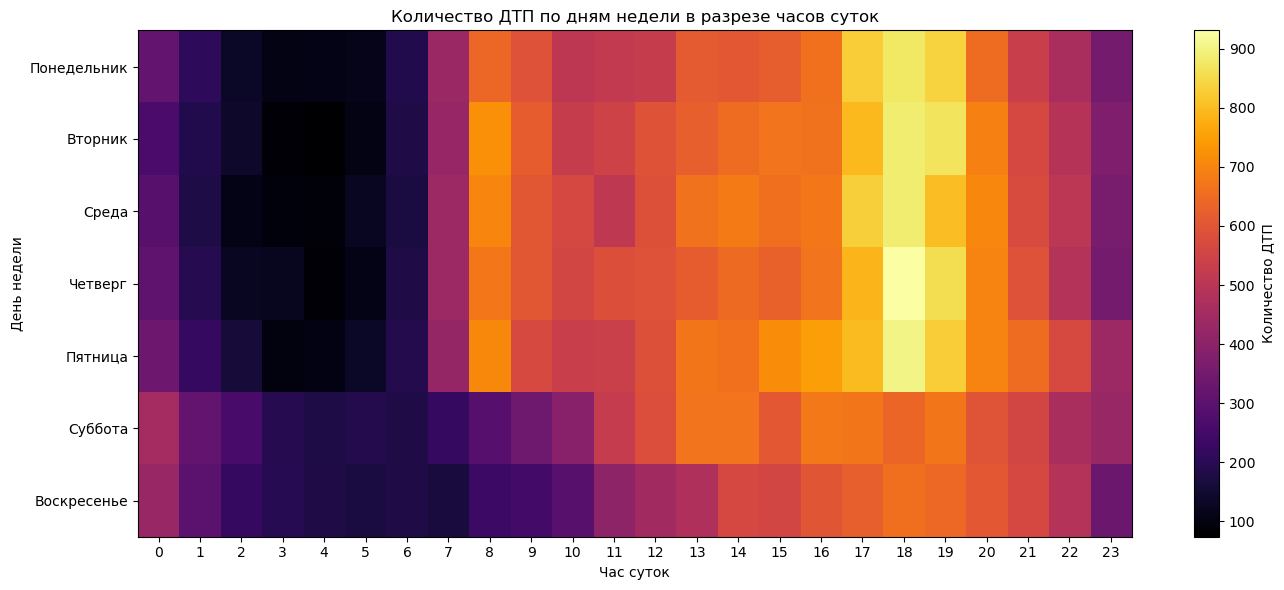

<Figure size 640x480 with 0 Axes>

In [122]:
pivot = df.pivot_table(index="weekday", columns="hour", aggfunc="size", fill_value=0)
pivot = pivot.reindex(index=range(7), columns=range(24), fill_value=0)

plt.figure(figsize=(14, 6)) 

plt.imshow(pivot.values, cmap="inferno", aspect="auto")

plt.xticks(range(24), range(24))
plt.yticks(range(7), weekday_names)

plt.xlabel("Час суток")
plt.ylabel("День недели")
plt.title("Количество ДТП по дням недели в разрезе часов суток")

plt.colorbar(label="Количество ДТП")

plt.tight_layout()
plt.show()
plt.savefig("dtp_by_hour.png", dpi=300, bbox_inches="tight") 

plt.show()

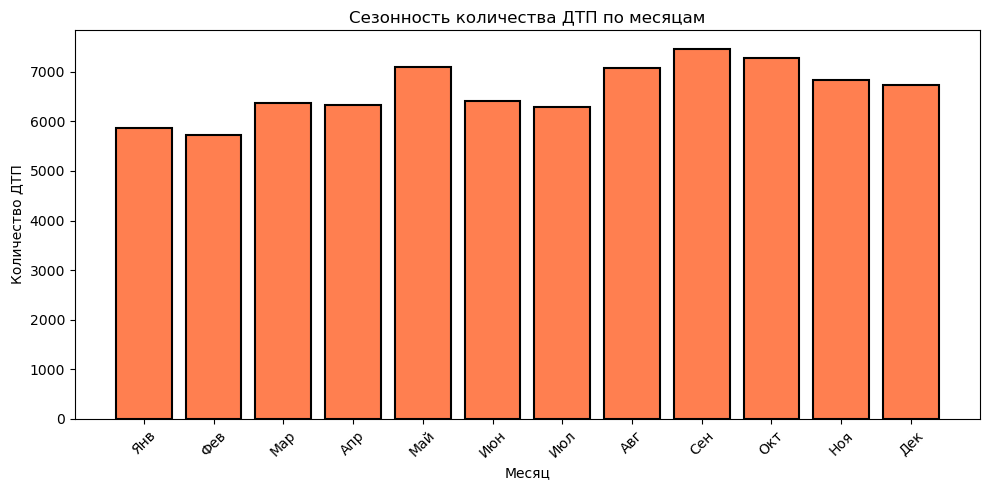

<Figure size 640x480 with 0 Axes>

In [123]:
monthly_counts = df.groupby("month").size().reindex(range(1, 13), fill_value=0)

months = [
    "Янв", "Фев", "Мар", "Апр", "Май", "Июн",
    "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"
]

plt.figure(figsize=(10,5))

plt.bar(
    monthly_counts.index, 
    monthly_counts.values,
    color="#FF7F50",
    edgecolor="black",
    linewidth=1.5
)

plt.xticks(ticks=range(1,13), labels=months, rotation=45)
plt.xlabel("Месяц")
plt.ylabel("Количество ДТП")
plt.title("Сезонность количества ДТП по месяцам")

plt.tight_layout()
plt.show()
plt.savefig("dtp_by_hour.png", dpi=300, bbox_inches="tight") 

plt.show()

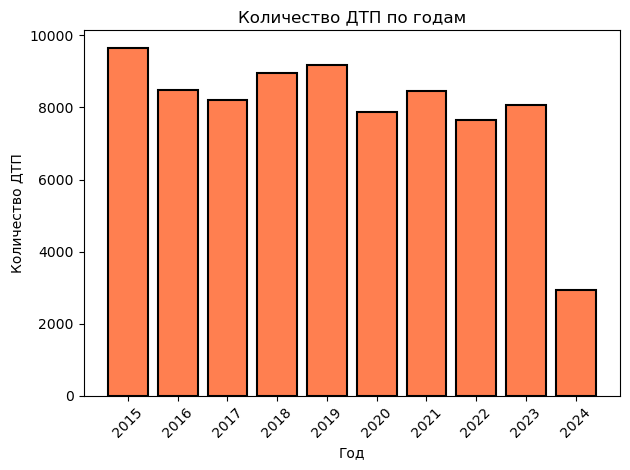

<Figure size 640x480 with 0 Axes>

In [124]:
df["datetime"] = pd.to_datetime(df["datetime"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["datetime"]).copy()

df["year"] = df["datetime"].dt.year
year_counts = df["year"].value_counts().sort_index()

plt.figure()
plt.bar(
    year_counts.index, 
   year_counts.values,
    color="#FF7F50",
    edgecolor="black",
    linewidth=1.5
)
plt.xticks(year_counts.index, rotation=45)
plt.xlabel("Год")
plt.ylabel("Количество ДТП")
plt.title("Количество ДТП по годам")

plt.tight_layout()
plt.show()
plt.savefig("dtp_by_hour.png", dpi=300, bbox_inches="tight") 

plt.show()

In [105]:
df["road_conditions"] = df["road_conditions"].astype(str)


def classify_surface(text):
    text = text.lower()
    
    if "сух" in text:
        return "Сухое покрытие"
    elif "мокр" in text:
        return "Мокрое покрытие"
    elif "снег" in text or "заснеж" in text:
        return "Снежное покрытие"
    elif "голол" in text or "лед" in text:
        return "Гололёд"
    else:
        return "Прочее"

df["surface_group"] = df["road_conditions"].apply(classify_surface)


surface_counts = df["surface_group"].value_counts()

print(surface_counts)

surface_group
Сухое покрытие      48994
Мокрое покрытие     20689
Гололёд              6274
Снежное покрытие     3064
Прочее                469
Name: count, dtype: int64


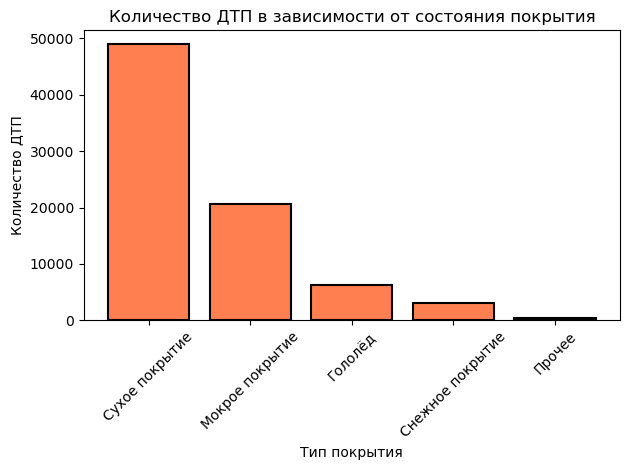

<Figure size 640x480 with 0 Axes>

In [125]:
plt.figure()
plt.bar(
    surface_counts.index, 
    surface_counts.values,
    color="#FF7F50",
    edgecolor="black",
    linewidth=1.5
)

plt.xticks(rotation=45)
plt.xlabel("Тип покрытия")
plt.ylabel("Количество ДТП")
plt.title("Количество ДТП в зависимости от состояния покрытия")
plt.tight_layout()
plt.show()
plt.savefig("dtp_by_hour.png", dpi=300, bbox_inches="tight") 

plt.show()

In [107]:
df["road_conditions"] = df["road_conditions"].astype(str)
df["severity"] = df["severity"].astype(str)


def classify_surface(text):
    text = text.lower()
    
    if "сух" in text:
        return "Сухое покрытие"
    elif "мокр" in text:
        return "Мокрое покрытие"
    elif "снег" in text or "заснеж" in text:
        return "Снежное покрытие"
    elif "голол" in text or "лед" in text:
        return "Гололёд"
    else:
        return "Прочее"

df["surface_group"] = df["road_conditions"].apply(classify_surface)


df["is_severe"] = df["severity"].str.contains("Тяж|погиб", case=False, na=False)


result = df.groupby("surface_group").agg(
    total_accidents=("is_severe", "count"),
    severe_accidents=("is_severe", "sum")
)

result["severe_share_%"] = (
    result["severe_accidents"] / result["total_accidents"] * 100
).round(2)

result = result.sort_values("severe_share_%", ascending=False)

result

,total_accidents,severe_accidents,severe_share_%
surface_group,,,
Мокрое покрытие,20689,6002,29.01
Сухое покрытие,48994,13434,27.42
Гололёд,6274,1646,26.24
Снежное покрытие,3064,789,25.75
Прочее,469,120,25.59


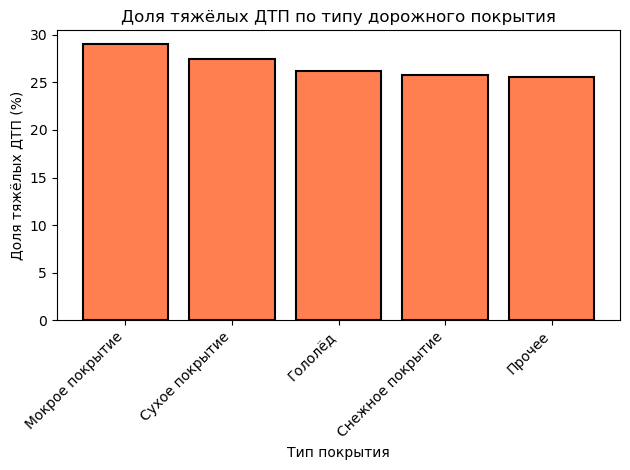

In [108]:
plt.figure()
plt.bar(result.index, result["severe_share_%"])
plt.bar(
    result.index, result["severe_share_%"], 
    color="#FF7F50",
    edgecolor="black",
    linewidth=1.5
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Тип покрытия")
plt.ylabel("Доля тяжёлых ДТП (%)")
plt.title("Доля тяжёлых ДТП по типу дорожного покрытия")
plt.tight_layout()
plt.show()

In [109]:
def classify_surface(text: str) -> str:
    t = text.lower()
    if "сух" in t:
        return "Сухое"
    elif "мокр" in t:
        return "Мокрое"
    elif "снег" in t or "заснеж" in t:
        return "Снежное"
    elif "голол" in t or "лед" in t:
        return "Гололёд"
    else:
        return "Прочее"

df["surface_group"] = df["road_conditions"].apply(classify_surface)


pivot_cnt = df.pivot_table(
    index="surface_group",
    columns="hour",
    aggfunc="size",
    fill_value=0
).reindex(columns=range(24), fill_value=0)

order = ["Сухое", "Мокрое", "Снежное", "Гололёд", "Прочее"]
pivot_cnt = pivot_cnt.reindex([x for x in order if x in pivot_cnt.index])


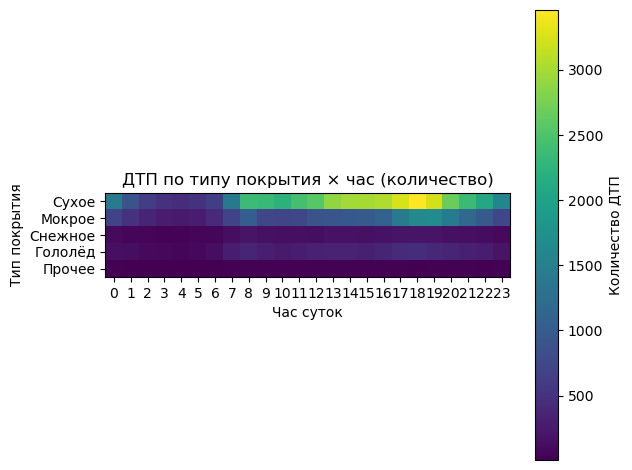

In [126]:
plt.figure()
plt.imshow(pivot_cnt.values)
plt.xticks(range(24), range(24))
plt.yticks(range(len(pivot_cnt.index)), pivot_cnt.index)
plt.xlabel("Час суток")
plt.ylabel("Тип покрытия")
plt.title("ДТП по типу покрытия × час (количество)")
plt.colorbar(label="Количество ДТП")
plt.tight_layout()
plt.show()

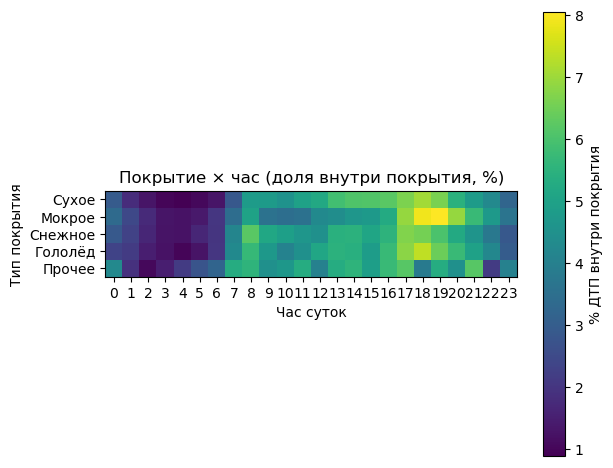

In [127]:
pivot_pct = pivot_cnt.div(pivot_cnt.sum(axis=1), axis=0) * 100

plt.figure()
plt.imshow(pivot_pct.values)
plt.xticks(range(24), range(24))
plt.yticks(range(len(pivot_pct.index)), pivot_pct.index)
plt.xlabel("Час суток")
plt.ylabel("Тип покрытия")
plt.title("Покрытие × час (доля внутри покрытия, %)")
plt.colorbar(label="% ДТП внутри покрытия")
plt.tight_layout()
plt.show()


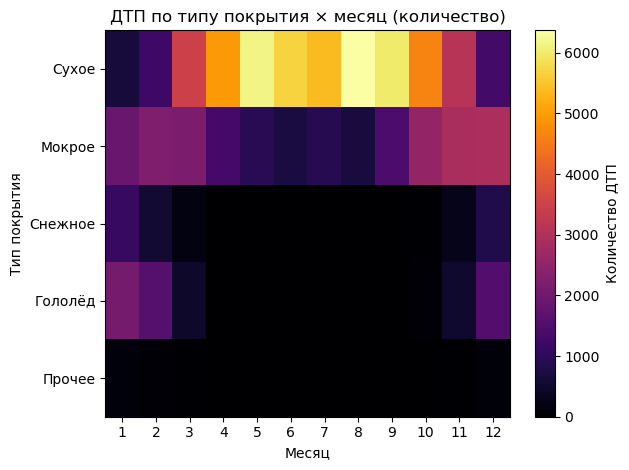

In [128]:
pivot_cnt1 = df.pivot_table(
    index="surface_group",
    columns="month",
    aggfunc="size",
    fill_value=0
).reindex(columns=range(1,13), fill_value=0)

order = ["Сухое", "Мокрое", "Снежное", "Гололёд", "Прочее"]
pivot_cnt1 = pivot_cnt1.reindex([x for x in order if x in pivot_cnt1.index])

plt.figure()
plt.imshow(pivot_cnt1.values, cmap="inferno", aspect="auto")
plt.xticks(range(12), range(1,13))
plt.yticks(range(len(pivot_cnt1.index)), pivot_cnt1.index)
plt.xlabel("Месяц")
plt.ylabel("Тип покрытия")
plt.title("ДТП по типу покрытия × месяц (количество)")
plt.colorbar(label="Количество ДТП")
plt.tight_layout()
plt.show()

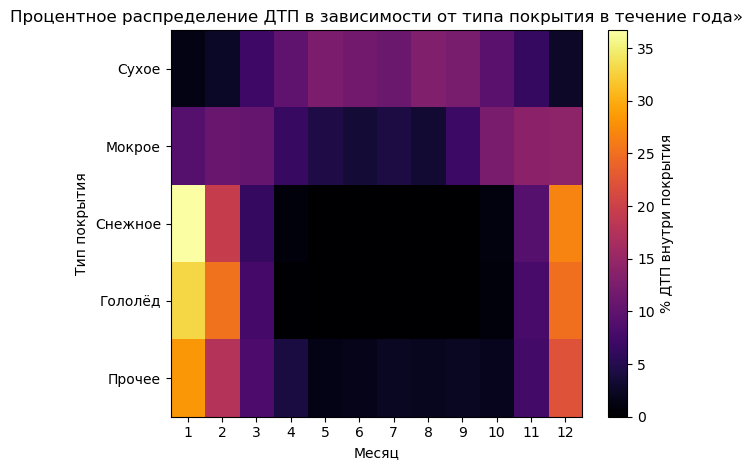

In [113]:
pivot_pct = pivot_cnt1.div(pivot_cnt.sum(axis=1), axis=0) * 100

plt.figure()
plt.imshow(pivot_pct.values, cmap="inferno", aspect="auto")
plt.xticks(range(12), range(1,13))
plt.yticks(range(len(pivot_pct.index)), pivot_pct.index)
plt.xlabel("Месяц")
plt.ylabel("Тип покрытия")
plt.title("Процентное распределение ДТП в зависимости от типа покрытия в течение года»")
plt.colorbar(label="% ДТП внутри покрытия")
plt.tight_layout()
plt.show()

In [114]:
df["weather"] = df["weather"].astype(str)
df["severity"] = df["severity"].astype(str)

def classify_weather(text: str) -> str:
    t = text.lower()
    
    if "яс" in t:
        return "Ясно"
    elif "пасмур" in t or "облач" in t:
        return "Пасмурно"
    elif ("дожд" in t or "снег" in t or "осад" in t or 
          "лив" in t or "туман" in t or "метел" in t):
        return "Осадки"
    else:
        return "Прочее"

df["weather_group"] = df["weather"].apply(classify_weather)

weather_counts = df["weather_group"].value_counts()
print(weather_counts)

weather_group
Пасмурно    40720
Ясно        34086
Осадки       4684
Name: count, dtype: int64


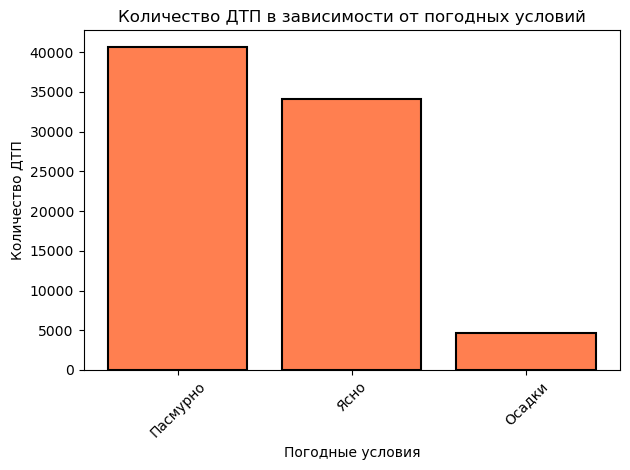

In [115]:
plt.figure()
plt.bar(
    weather_counts.index, weather_counts, 
    color="#FF7F50",
    edgecolor="black",
    linewidth=1.5
)
plt.xticks(rotation=45)
plt.xlabel("Погодные условия")
plt.ylabel("Количество ДТП")
plt.title("Количество ДТП в зависимости от погодных условий")

plt.tight_layout()
plt.show()

In [116]:
df["is_severe"] = df["severity"].str.contains("Тяж|погиб", case=False, na=False)

result_weather = df.groupby("weather_group").agg(
    total_accidents=("is_severe", "count"),
    severe_accidents=("is_severe", "sum")
)

result_weather["severe_share_%"] = (
    result_weather["severe_accidents"] / result_weather["total_accidents"] * 100
).round(2)

result_weather = result_weather.sort_values("severe_share_%", ascending=False)

result_weather

,total_accidents,severe_accidents,severe_share_%
weather_group,,,
Осадки,4684,1625,34.69
Ясно,34086,9783,28.70
Пасмурно,40720,10583,25.99


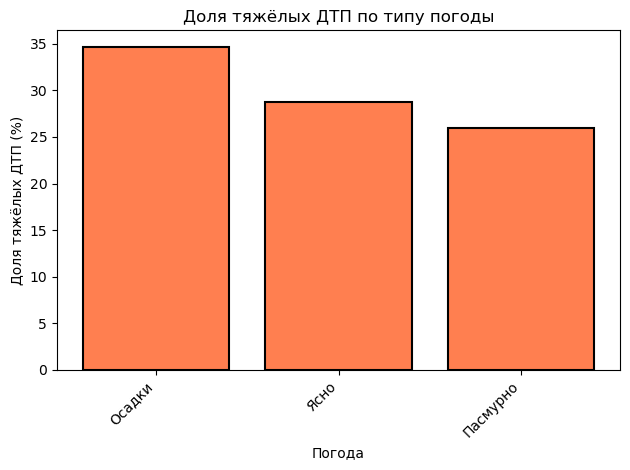

In [117]:
plt.figure()
plt.bar(result_weather.index, result_weather["severe_share_%"])
plt.bar(
    result_weather.index, result_weather["severe_share_%"], 
    color="#FF7F50",
    edgecolor="black",
    linewidth=1.5
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Погода")
plt.ylabel("Доля тяжёлых ДТП (%)")
plt.title("Доля тяжёлых ДТП по типу погоды")
plt.tight_layout()
plt.show()

In [118]:
pivot_weather_hour = df.pivot_table(
    index="weather_group",
    columns="hour",
    aggfunc="size",
    fill_value=0
).reindex(columns=range(24), fill_value=0)

pivot_weather_hour

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weather_group,,,,,,,,,,,,,,,,,,,,,
Осадки,188,122,100,68,57,68,93,144,202,169,...,196,186,207,341,369,405,375,305,269,187
Пасмурно,1409,992,658,518,468,516,713,1318,1934,1509,...,2004,2051,2278,2761,3172,3129,2711,2415,2043,1573
Ясно,801,493,392,304,287,364,463,1083,1844,1896,...,2283,2223,2214,2240,2235,1984,1561,1317,1149,876


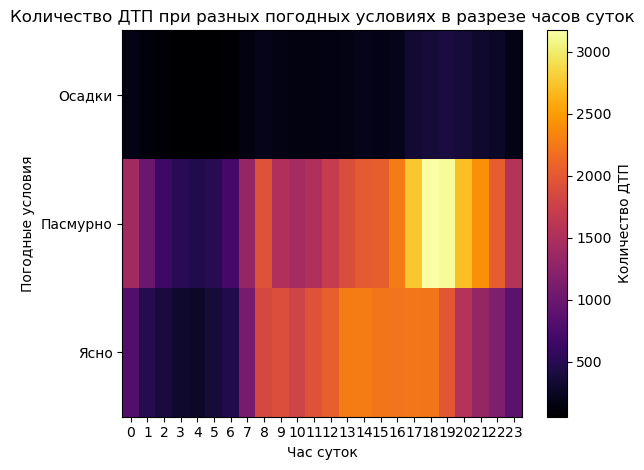

In [119]:
plt.figure()
plt.imshow(pivot_weather_hour.values, cmap="inferno", aspect="auto")
plt.xticks(range(24), range(24))
plt.yticks(range(len(pivot_weather_hour.index)), pivot_weather_hour.index)
plt.xlabel("Час суток")
plt.ylabel("Погодные условия")
plt.title("Количество ДТП при разных погодных условиях в разрезе часов суток")
plt.colorbar(label="Количество ДТП")
plt.tight_layout()
plt.show()

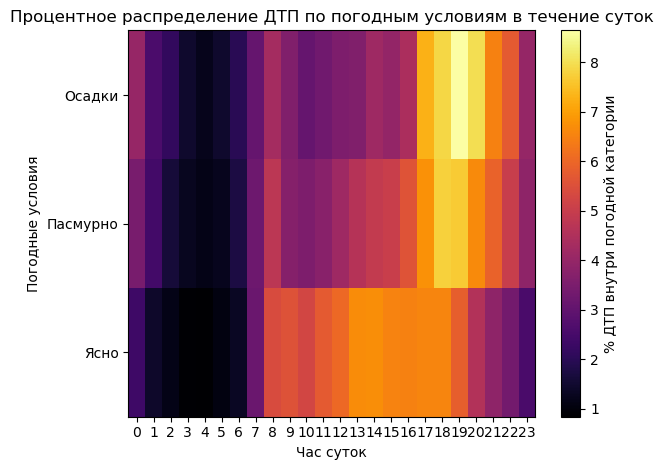

In [120]:
pivot_weather_pct = pivot_weather_hour.div(
    pivot_weather_hour.sum(axis=1), axis=0
) * 100

plt.figure()
plt.imshow(pivot_weather_pct.values, cmap="inferno", aspect="auto")
plt.xticks(range(24), range(24))
plt.yticks(range(len(pivot_weather_pct.index)), pivot_weather_pct.index)
plt.xlabel("Час суток")
plt.ylabel("Погодные условия")
plt.title("Процентное распределение ДТП по погодным условиям в течение суток")
plt.colorbar(label="% ДТП внутри погодной категории")
plt.tight_layout()
plt.show()